<a href="https://colab.research.google.com/github/sromac19/rinbp25/blob/main/celeb_faces_vae_trained_perceptual_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("arnrob/celeba-small-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 319M/319M [00:02<00:00, 120MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1


In [2]:
path = "/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1"

!ls -lah "{path}"
!find "{path}" -maxdepth 2 -type d | head -n 50

total 5.5M
drwxr-xr-x 5 root root 4.0K Feb 20 00:23 .
drwxr-xr-x 3 root root 4.0K Feb 20 00:22 ..
drwxr-xr-x 2 root root 524K Feb 20 00:22 testing
drwxr-xr-x 2 root root 4.4M Feb 20 00:23 training
drwxr-xr-x 2 root root 536K Feb 20 00:23 validation
/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1
/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1/validation
/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1/training
/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1/testing


In [19]:
import os
import warnings
import json
import datetime
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import CenterCrop, Resizing, Rescaling
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

# Constants
batch_size = 64
img_path = "/root/.cache/kagglehub/datasets/arnrob/celeba-small-images-dataset/versions/1/"

# Introduction

**Reminder :** A Variational Autoencoder (VAE) is a type of autoencoder with added constraints on the encoded representations being learnt : instead of letting the neural network organize arbitrarily the latent space, it forces the latent space to be well organized (normally distributed). This property makes VAE deep generative models. Indeed, one can take a point randomly from that latent space and decode it to get a new image.

The parameters of a "standard" autoencoder are trained via a *reconstruction loss* (typically a pixel-by-pixel loss) that the model training will try to minimize, forcing the output (reconstructed image) to match the initial input (original image).

The parameters of a VAE are trained via two loss functions: a *reconstruction loss* (just like in our previous autoencoders), and the *KL divergence* between the learned latent distribution and the expected latent distribution (normal distribution). The *KL loss* will force the model to organize well the latent space (points in latent space should therefore be normally distributed).

If you are not familiar with these types of neural networks, you can find some useful links in the Reference section.

**What will you find in this notebook?** I trained 2 Variational Autoencoders (VAE) using the images from the famous [Celebrity Faces Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset).   

The model architecture is identical and copied from this research paper [Deep Feature Consistent Variational Autoencoder](https://arxiv.org/pdf/1610.00291.pdf), it is a deep CNN-based Variational Autoencoder:

![architecture autoencoder.PNG](attachment:1149ae00-5200-4666-9d96-fd87110d89d3.PNG)

The difference between the 2 models comes from the loss function :

* The Plain VAE (PVAE) uses a pixel-by-pixel measurement (MSE) to measure the difference between the reconstructed and the original images.  

* The VAE_123 was trained by replacing the pixel-by-pixel loss with feature perceptual loss, which is defined as the difference between two images’ hidden representations extracted from a pretrained deep CNN (VGGNet trained on ImageNet). It is called VAE_123 since the loss function uses the hidden representations extracted from the convolutional blocks 1, 2 and 3 from the pretrained VGGNet.

The left is a deep CNN-based Variational Autoencoder and the right is a pretrained deep CNN used to compute
feature perceptual loss.

![model overview.PNG](attachment:edbaa7ad-6928-470b-85cc-f17e4b094ce4.PNG)

**Why Perceptual Loss?** This research paper [Deep Feature Consistent Variational Autoencoder](https://arxiv.org/pdf/1610.00291.pdf) introduced a new method for training VAE with Perceptual Loss and showed that the outputs had a more natural visual appearance and better perceptual quality than images generated with plain VAE.

# Prepare the Dataset

The original dataset [CelebFaces Attributes (CelebA) Dataset](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) has 202,599 face images of various celebrities. Each image has a shape of (218,178,3).  

The authors of this research paper [Deep Feature Consistent Variational Autoencoder](https://arxiv.org/pdf/1610.00291.pdf) use a slightly different version of this dataset as the images are cropped around the center and resized to (64,64,3). I create a new dataset [CelebFaces Dataset - 64x64](https://www.kaggle.com/datasets/arnrob/celeba-small-images-dataset) after cropping and resizing images accordingly. Besides, I store each image in either the "training" or the "validation" or the "testing" folder:
* images 1-162770 are training,
* images 162771-182637 are validation,
* images 182638-202599 are testing.

**The dataset is pretty large. We therefore use GPU and Dataset objects since they will take care of performance-critical details.**

In [49]:
import tensorflow as tf

IMG_SIZE = (64, 64)  # jer tvoj encoder prima (64,64,3)

def process_path(file_path):
    img_bytes = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0   # <- eksplicitno [0,1]
    return img, img


def configure_for_performance(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(2048, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = tf.data.Dataset.list_files(img_path + "training/*.jpg", shuffle=True)
val_ds   = tf.data.Dataset.list_files(img_path + "validation/*.jpg", shuffle=False)
test_ds  = tf.data.Dataset.list_files(img_path + "testing/*.jpg", shuffle=False)

train_ds = train_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = configure_for_performance(train_ds, shuffle=True)
val_ds   = configure_for_performance(val_ds, shuffle=False)
test_ds  = configure_for_performance(test_ds, shuffle=False)

Now, we can display a few celebrity faces:

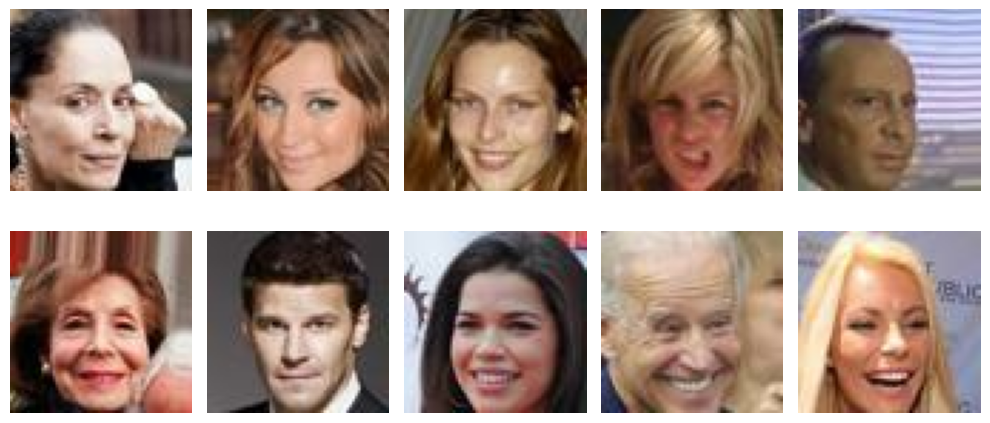

In [50]:
plt.figure(figsize=(10, 5))
for x, _ in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(x[i])
        plt.axis("off")
plt.tight_layout()
plt.show()

# Build the image preprocesser

In [51]:
from tensorflow import keras
from tensorflow.keras import layers, Model

def create_preprocesser():
    inputs = keras.Input(shape=(64, 64, 3), name="preprocess_input")
    outputs = layers.Lambda(lambda x: x, name="identity")(inputs)  # <- spaja graph
    return Model(inputs, outputs, name="preprocesser")

# Build the encoder

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

class Sampling(layers.Layer):
    def __init__(self, stddev=1.0, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean), mean=0.0, stddev=self.stddev)
        return z_mean + tf.exp(0.5 * z_log_var) * eps


def create_encoder(latent_dim=100, eps_std=1.0):
    inputs = keras.Input(shape=(64, 64, 3), name="encoder_input")

    x = layers.Conv2D(32, (4, 4), strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Conv2D(64, (4, 4), strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(stddev=eps_std, name="z")([z_mean, z_log_var])
    return Model(inputs, [z_mean, z_log_var, z], name="encoder")

# Build the decoder

In [53]:
from tensorflow import keras
from tensorflow.keras import layers, Model

def create_decoder(latent_dim=100, out_activation="sigmoid"):
    inputs = keras.Input(shape=(latent_dim,), name="decoder_input")  # <- tuple!

    x = layers.Dense(4 * 4 * 256, activation="relu")(inputs)
    x = layers.Reshape((4, 4, 256))(x)

    # 8x8
    x = layers.UpSampling2D((2, 2), interpolation="nearest")(x)
    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # 16x16
    x = layers.UpSampling2D((2, 2), interpolation="nearest")(x)
    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # 32x32
    x = layers.UpSampling2D((2, 2), interpolation="nearest")(x)
    x = layers.Conv2D(32, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # 64x64
    x = layers.UpSampling2D((2, 2), interpolation="nearest")(x)
    decoded = layers.Conv2D(3, (3, 3), padding="same", activation=out_activation, name="decoded")(x)

    return Model(inputs, decoded, name="decoder")

# Build and Train the Plain VAE

The PVAE is defined as a Model with a custom train_step. The loss function is : *loss = alpha x reconstruction_loss + beta x kl_loss*. Here the reconstruction loss is the pixel-by-pixel mean squared error between the input image and the generated one. I used Optuna framework to tune *alpha* and *beta*.

I trained the model with a batch size of 64 for 30 epochs over the training dataset and used Adam method for optimization with initial learning rate of 0.001, which is decreased by a factor of 0.2 on plateau.

In [54]:
import tensorflow as tf
from tensorflow import keras

class PVAE(keras.Model):
    def __init__(self, preprocesser, encoder, decoder, alpha=1.0, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.preprocesser = preprocesser
        self.encoder = encoder
        self.decoder = decoder
        self.alpha = alpha
        self.beta = beta

        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.loss_wo_weight_tracker = keras.metrics.Mean(name="loss_wo_weight")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        # Create once (Keras 3 safe)
        self.mse = keras.losses.MeanSquaredError()

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.loss_wo_weight_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def forward(self, x):
        x_p = self.preprocesser(x)
        z_mean, z_log_var, z = self.encoder(x_p)
        reconstruction = self.decoder(z)
        return x_p, z_mean, z_log_var, reconstruction

    def compute_loss(self, x_p, z_mean, z_log_var, reconstruction):
        # Reconstruction loss (x_p and reconstruction are same scale)
        reconstruction_loss = self.mse(x_p, reconstruction)

        # KL divergence with log-variance (z_log_var)
        kl = -0.5 * (1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl, axis=1))

        loss_wo_weight = reconstruction_loss + kl_loss
        loss = self.alpha * reconstruction_loss + self.beta * kl_loss
        return reconstruction_loss, kl_loss, loss, loss_wo_weight

    def train_step(self, data):
        # data can be x OR (x, y). For autoencoder we ignore y.
        x = data[0] if isinstance(data, (tuple, list)) else data

        with tf.GradientTape() as tape:
            x_p, z_mean, z_log_var, reconstruction = self.forward(x)
            reconstruction_loss, kl_loss, loss, loss_wo_weight = self.compute_loss(
                x_p, z_mean, z_log_var, reconstruction
            )

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.loss_wo_weight_tracker.update_state(loss_wo_weight)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.loss_tracker.result(),
            "loss_wo_weight": self.loss_wo_weight_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data

        x_p, z_mean, z_log_var, reconstruction = self.forward(x)
        reconstruction_loss, kl_loss, loss, loss_wo_weight = self.compute_loss(
            x_p, z_mean, z_log_var, reconstruction
        )

        self.loss_tracker.update_state(loss)
        self.loss_wo_weight_tracker.update_state(loss_wo_weight)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.loss_tracker.result(),
            "loss_wo_weight": self.loss_wo_weight_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, x, training=False):
        x_p, z_mean, z_log_var, reconstruction = self.forward(x)
        return reconstruction

In [55]:
print([o.name for o in pencoder.outputs])

['keras_tensor_145', 'keras_tensor_146', 'keras_tensor_147']


In [57]:
alpha = 1.0
beta  = 0.05
lr    = 3e-4

ppreprocesser = create_preprocesser()
pencoder = create_encoder()
pdecoder = create_decoder(latent_dim=100, out_activation="sigmoid")

pvae = PVAE(ppreprocesser, pencoder, pdecoder, alpha, beta)
pvae.compile(optimizer=keras.optimizers.Adam(learning_rate=lr))

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1, mode="min"),
    ModelCheckpoint("./pvae_best.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

history_pvae = pvae.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/15
2542/2543 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - kl_loss: 0.0015 - loss: 0.0682 - loss_wo_weight: 0.0696 - reconstruction_loss: 0.0681
Epoch 1: val_loss improved from inf to 0.06546, saving model to ./pvae_best.keras
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 74s 26ms/step - kl_loss: 0.0015 - loss: 0.0682 - loss_wo_weight: 0.0696 - reconstruction_loss: 0.0681 - val_kl_loss: 5.6203e-04 - val_loss: 0.0655 - val_loss_wo_weight: 0.0660 - val_reconstruction_loss: 0.0654 - learning_rate: 3.0000e-04
Epoch 2/15
2542/2543 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - kl_loss: 3.5559e-04 - loss: 0.0664 - loss_wo_weight: 0.0668 - reconstruction_loss: 0.0664
Epoch 2: val_loss improved from 0.06546 to 0.06544, saving model to ./pvae_best.keras
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - kl_loss: 3.5556e-04 - loss: 0.0664 - loss_wo_weight: 0.0668 - reconstruction_loss: 0.0664 - val_kl_loss: 1.8652e-04 - val_loss: 0.0654 - val_loss_wo_weight: 0.0656 - val_reconstruction_loss: 0.0654 - learning_rate: 3.0000e-04


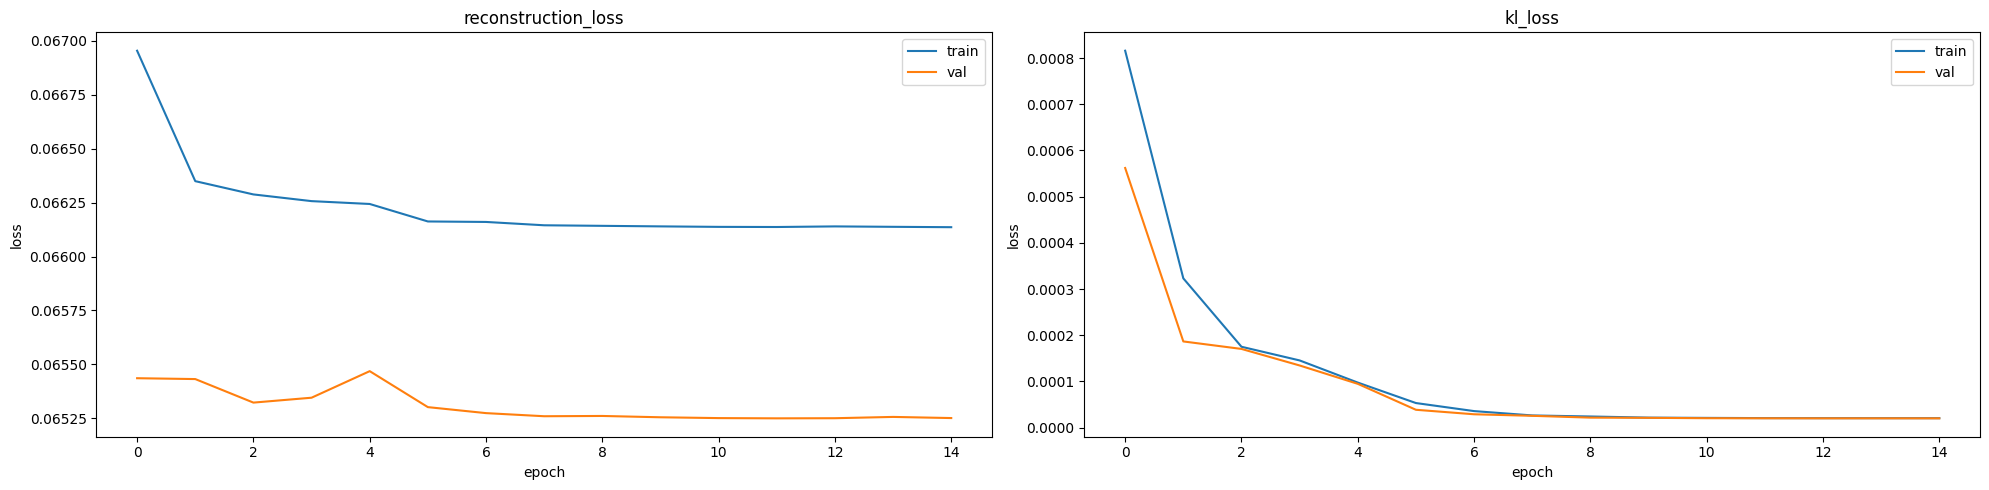

In [60]:
import matplotlib.pyplot as plt

def display_history(history):
    plt.figure(figsize=(20,5))

    # reconstruction
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("reconstruction_loss", []), label="train")
    plt.plot(history.history.get("val_reconstruction_loss", []), label="val")
    plt.title("reconstruction_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    # KL
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("kl_loss", []), label="train")
    plt.plot(history.history.get("val_kl_loss", []), label="val")
    plt.title("kl_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

display_history(history_pvae)

# Build and Train the VAE with Perceptual Loss

The VAE_123 is defined as a Model with a custom train_step. The loss function is : *loss = alpha x reconstruction_loss + beta x kl_loss*. Here the reconstruction loss is calculated differently : instead of directly comparing the input image and the generated image in the pixel space, we feed both of them to a pre-trained deep CNN (VGG19 trained on ImageNet)  respectively and then measure the difference between hidden layer representations. I tried different layer combinations to construct this (reconstruction) perceptual loss and ended up using layers relu1_1 and relu2_1. I used Optuna framework to tune *alpha* and *beta*. The VAE_123 model weights are initialized with the ones of the PVAE model. This "trick" was suggesting in this [post](https://stats.stackexchange.com/questions/341954/balancing-reconstruction-vs-kl-loss-variational-autoencoder) and really helped stabilize the training.   

I trained the model with a batch size of 64 for 30 epochs over the training dataset and used Adam method for optimization with initial learning rate of 0.001, which is decreased by a factor of 0.2 on plateau.

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.vgg19 import preprocess_input

class VAE_123(keras.Model):
    def __init__(self, preprocesser, encoder, decoder, alpha, beta, vgg19_123, **kwargs):
        super().__init__(**kwargs)
        self.preprocesser = preprocesser
        self.encoder = encoder
        self.decoder = decoder
        self.vgg19_123 = vgg19_123

        self.alpha = alpha
        self.beta = beta

        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        self.mse = keras.losses.MeanSquaredError()

    @property
    def metrics(self):
        return [self.loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def forward(self, x):
        x_p = self.preprocesser(x)  # očekujemo [0,1] i shape (64,64,3)
        z_mean, z_log_var, z = self.encoder(x_p)
        reconstruction = self.decoder(z)  # sigmoid -> [0,1]
        return x_p, z_mean, z_log_var, reconstruction

    def perceptual_loss(self, x_p, reconstruction):
        # VGG19 preprocess_input očekuje 0-255 RGB; mi imamo [0,1]
        x255 = x_p * 255.0
        r255 = reconstruction * 255.0

        x_vgg = preprocess_input(x255)
        r_vgg = preprocess_input(r255)

        f1_x, f2_x, f3_x = self.vgg19_123(x_vgg)
        f1_r, f2_r, f3_r = self.vgg19_123(r_vgg)

        loss_1 = self.mse(f1_x, f1_r)   # relu1_1
        loss_2 = self.mse(f2_x, f2_r)   # relu2_1

        return 0.5 * (loss_1 + loss_2)

    def compute_loss(self, x_p, z_mean, z_log_var, reconstruction):
        recon_loss = self.perceptual_loss(x_p, reconstruction)

        kl = -0.5 * (1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl, axis=1))

        loss = self.alpha * recon_loss + self.beta * kl_loss
        return recon_loss, kl_loss, loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data

        with tf.GradientTape() as tape:
            x_p, z_mean, z_log_var, reconstruction = self.forward(x)
            recon_loss, kl_loss, loss = self.compute_loss(x_p, z_mean, z_log_var, reconstruction)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data

        x_p, z_mean, z_log_var, reconstruction = self.forward(x)
        recon_loss, kl_loss, loss = self.compute_loss(x_p, z_mean, z_log_var, reconstruction)

        self.loss_tracker.update_state(loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, x, training=False):
        x_p, z_mean, z_log_var, reconstruction = self.forward(x)
        return reconstruction

In [63]:
alpha = 1.0
beta  = 0.1
lr    = 1e-4

# VGG feature extractor
vgg19 = VGG19(include_top=False, weights="imagenet", input_shape=(64, 64, 3))
vgg19.trainable = False

vgg19_123 = Model(
    inputs=vgg19.input,
    outputs=[
        vgg19.get_layer("block1_conv1").output,
        vgg19.get_layer("block2_conv1").output,
        vgg19.get_layer("block3_conv1").output,
    ],
    name="vgg19_123",
)
vgg19_123.trainable = False

# Build models
preprocesser_123 = create_preprocesser()
encoder_123 = create_encoder(latent_dim=100)     # mora match latent_dim
decoder_123 = create_decoder(latent_dim=100, out_activation="sigmoid")

# Warm-start from PVAE
encoder_123.set_weights(pencoder.get_weights())
decoder_123.set_weights(pdecoder.get_weights())

# Build + compile
vae_123 = VAE_123(preprocesser_123, encoder_123, decoder_123, alpha, beta, vgg19_123)
vae_123.compile(optimizer=keras.optimizers.Adam(learning_rate=lr))

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1, mode="min"),
    ModelCheckpoint(filepath="./vae_123_best.keras", monitor="val_loss", verbose=1, save_best_only=True),
]

history_123 = vae_123.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/15
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - kl_loss: 387.9355 - loss: 18895.5762 - reconstruction_loss: 18856.7891
Epoch 1: val_loss improved from inf to 13447.75000, saving model to ./vae_123_best.keras
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 146s 53ms/step - kl_loss: 387.9712 - loss: 18894.5312 - reconstruction_loss: 18855.7383 - val_kl_loss: 527.8474 - val_loss: 13447.7500 - val_reconstruction_loss: 13394.9775 - learning_rate: 1.0000e-04
Epoch 2/15
2542/2543 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - kl_loss: 517.7928 - loss: 12896.9922 - reconstruction_loss: 12845.2051
Epoch 2: val_loss improved from 13447.75000 to 11341.03027, saving model to ./vae_123_best.keras
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 132s 52ms/step - kl_loss: 517.7915 - loss: 12896.5352 - reconstruction_loss: 12844.7490 - val_kl_loss: 500.7630 - val_loss: 11341.0303 - val_reconstruction_loss: 11290.9551 - learning_rate: 1.0000e-04
Epoch 3/15
2543/2543 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - kl_loss: 507.3378 - loss: 11052.9922 

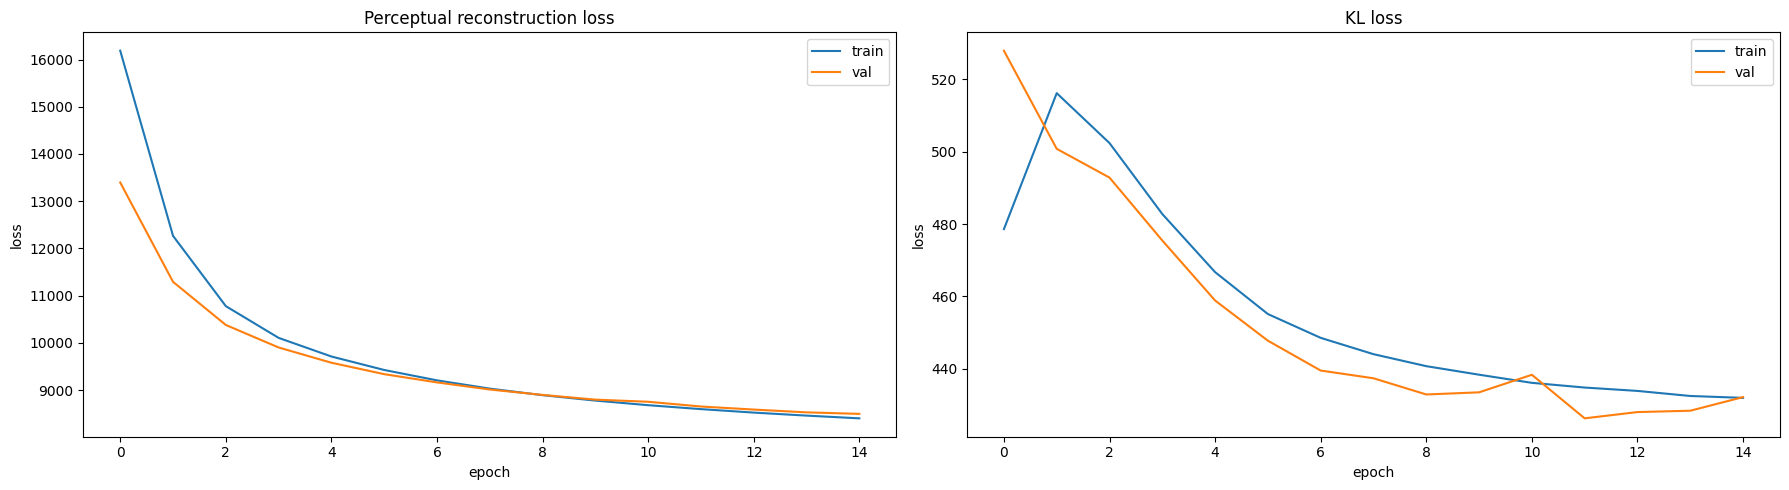

In [64]:
import matplotlib.pyplot as plt

def display_history(history):
    plt.figure(figsize=(18,5))

    plt.subplot(1,2,1)
    plt.plot(history.history.get("reconstruction_loss", []), label="train")
    plt.plot(history.history.get("val_reconstruction_loss", []), label="val")
    plt.title("Perceptual reconstruction loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history.get("kl_loss", []), label="train")
    plt.plot(history.history.get("val_kl_loss", []), label="val")
    plt.title("KL loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

display_history(history_123)

# Reconstruction : which one is the best?

In [73]:
def display_rec_images_from_dataset(model, ds, n=5):

    for x, _ in ds.take(1):
        recon = model(x, training=False)

        x = x.numpy()
        recon = recon.numpy()

        plt.figure(figsize=(20,5))
        for i in range(n):

            plt.subplot(2, n, i+1)
            plt.imshow(np.clip(x[i], 0, 1))
            plt.axis("off")

            plt.subplot(2, n, n+i+1)
            plt.imshow(np.clip(recon[i], 0, 1))
            plt.axis("off")

        plt.tight_layout()
        plt.show()
        break

Celebrity faces reconstructed using the Plain VAE (top : original images, bottom : reconstructed images) :

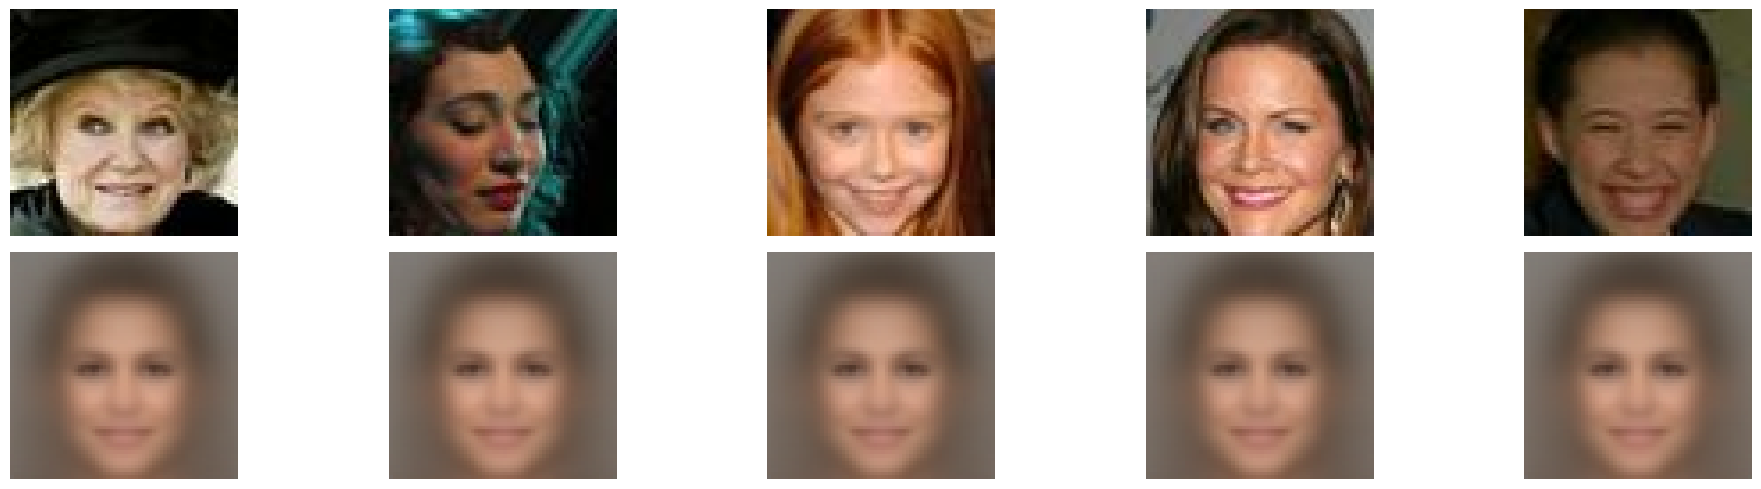

In [74]:
display_rec_images_from_dataset(pvae, test_ds)

Celebrity faces reconstructed using VAE_123 :

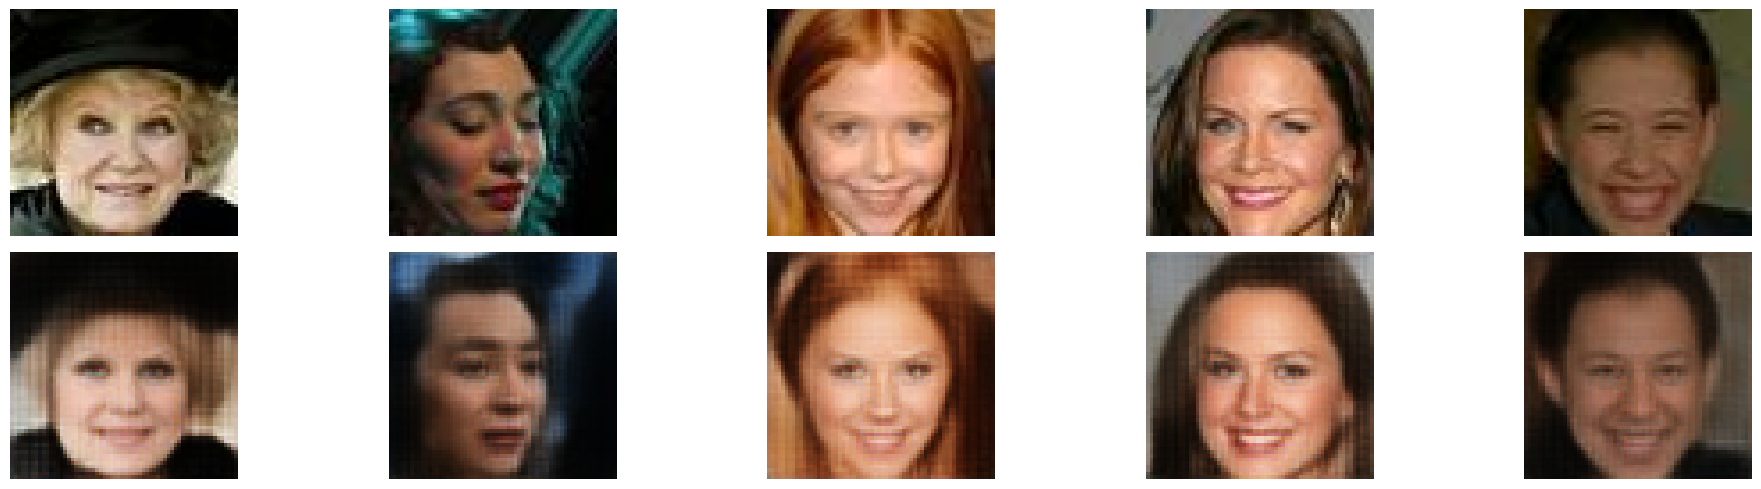

In [75]:
display_rec_images_from_dataset(vae_123, test_ds)

# Generate new face images : which one is the best?

In [79]:
import numpy as np
import matplotlib.pyplot as plt

def display_fake_images(decoder):
    # z ~ N(0,1) iz 100-dim latent prostora
    z = np.random.normal(0.0, 1.0, size=(10, 100)).astype("float32")

    fakefaces = decoder(z, training=False).numpy()  # (10,64,64,3) u [0,1]

    plt.figure(figsize=(20, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(np.clip(fakefaces[i], 0, 1))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

We generate new face images from 100-dimension latent vector z ∼ N (0, 1) from the decoder network of plain variational autoencoder (PVAE) trained with pixel-based loss :

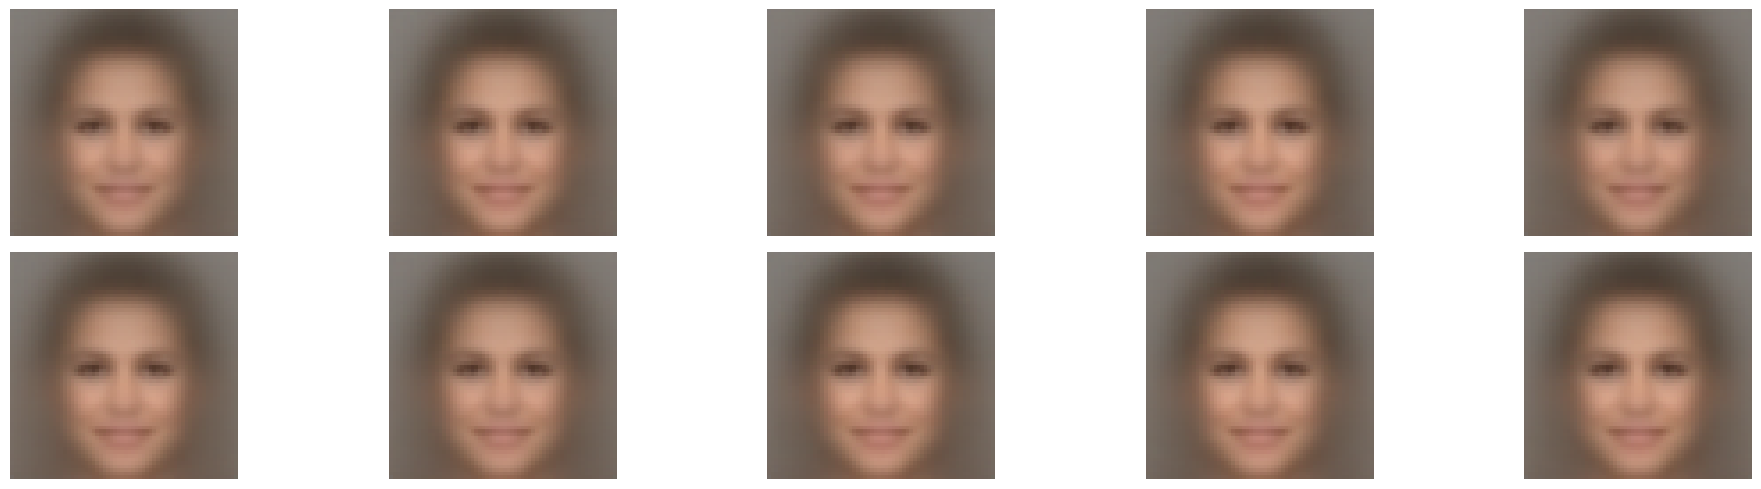

In [80]:
display_fake_images(pdecoder)

We generate new face images from 100-dimension latent vector z ∼ N (0, 1) from the decoder network of plain variational autoencoder (VAE_123) trained with perceptual loss :

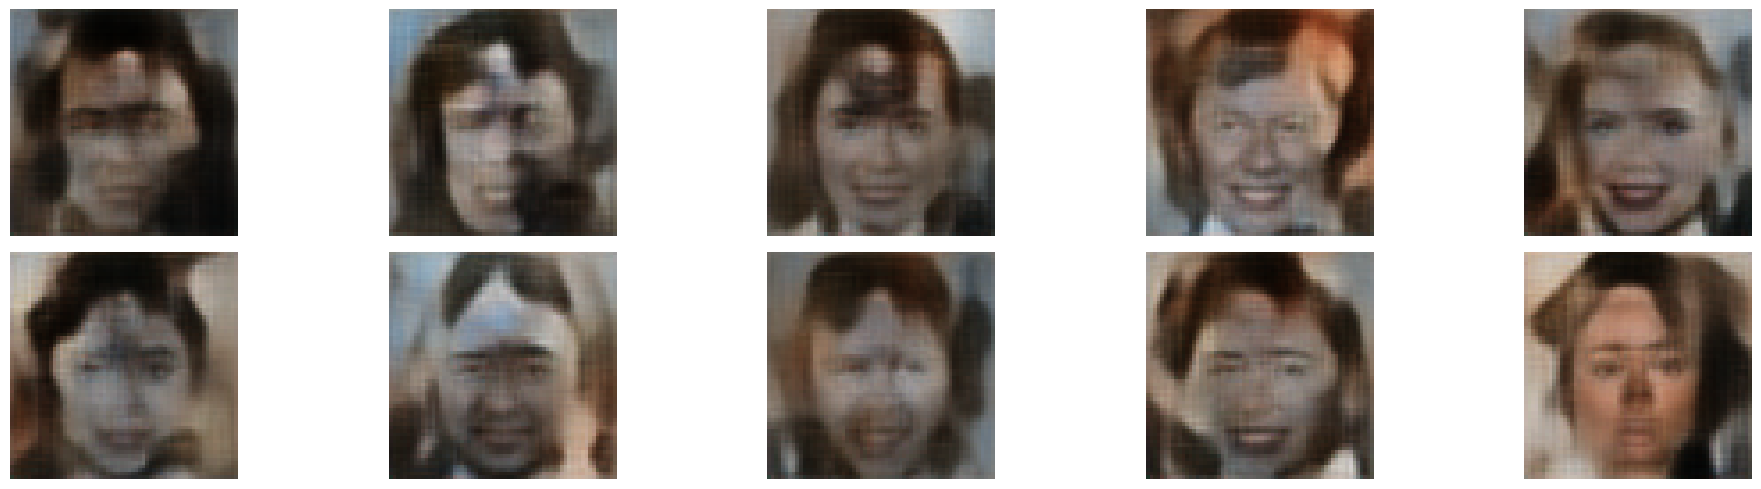

In [81]:
display_fake_images(decoder_123)

# Conclusion

The results are far from being as good as the ones presented in the research paper. I'm just a newbie :-) after all.

That said, I'm quite happy with the results of the Plain VAE, the reconstruction is not so bad and even the generated images are OK... The results with the VAE trained with the Perception Loss are quite poor...

I found it very hard to tune these VAE, especially the VAE trained with Perception Loss :

* One problem is that the reconstruction loss dominates the KL loss during the training leading to "pretty good" reconstruction (at least for the plain VAE) but poor capability to generate new realistic images :
![losses during training.png](attachment:df12de2b-e62e-43c2-975a-afeafdb3bfea.png)
Introducing weights (loss = alpha x reconstruction_loss + beta x kl_loss) and tuning the alpha and beta with Optuna helped a bit but there is still room for improvement.

* Another problem is that, when using the Perception Loss, the training was very unstable until I implemented that idea of "warming up" the KL loss term by starting at zero and training a bit on just reconstruction loss before introducing the KL loss.
